# 05 · Measured turbulence — Reynolds-stress mode

When the tower reports the measured velocity statistics (σ_u, σ_v, σ_w and the
covariances), `TowerTurbulence` **overrides** the parameterized turbulence and
`mode="reynolds"` drives the full 3-D correlated Langevin engine. Here we run the
same period twice — parameterized vs. measured — to see the effect of measured
anisotropy on the footprint.

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt

import lagranged as lg

## Inputs and measured turbulence

`cov_uw ≈ −u*²` in streamwise-aligned coordinates. Supplying all three variances
lets `TowerTurbulence` assemble the full Reynolds-stress matrix that the 3-D drift
term needs.

In [2]:
inputs = lg.FootprintInputs(
    zm=3.0, z0=0.03, d=0.2, L=-50.0, ustar=0.35,
    umean=2.4, wind_dir=210.0, h=1000.0, sigma_v=0.6,
)
grid = lg.DomainGrid(nx=70, ny=70, dx=4.0, dy=4.0, x0=-80.0, y0=-140.0)
FAST = dict(n_particles=600, dt_factor=0.05, t_max=100.0, rebound_height=0.5, seed=7)

tower = lg.TowerTurbulence(
    sigma_u=0.85, sigma_v=0.60, sigma_w=0.42,
    cov_uw=-0.12,   # ≈ -u*^2
    cov_uv=0.03,
    cov_vw=-0.01,
)
print("Reynolds-stress matrix ⟨u_i' u_j'⟩ [m² s⁻²]:")
print(tower.reynolds_stress().matrix)

Reynolds-stress matrix ⟨u_i' u_j'⟩ [m² s⁻²]:
[[ 0.7225  0.03   -0.12  ]
 [ 0.03    0.36   -0.01  ]
 [-0.12   -0.01    0.1764]]


## Parameterized baseline vs. measured Reynolds-stress run

The first run supplies **no** tower turbulence, so the model falls back to its MOST
parameterizations (and emits a warning — the "measured-overrides-parameterized"
principle in action). The second feeds the measured statistics with
`mode="reynolds"`.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # expected: parameterized-turbulence notice
    param = lg.FootprintModel(
        inputs, grid=grid, config=lg.ModelConfig(mode="param", **FAST)
    ).run()

reyn = lg.FootprintModel(
    inputs, grid=grid, turbulence=tower,
    config=lg.ModelConfig(mode="reynolds", **FAST),
).run()

print(f"parameterized : x_peak = {param.x_peak:6.1f} m   touchdowns = {param.n_touchdowns}")
print(f"reynolds      : x_peak = {reyn.x_peak:6.1f} m   touchdowns = {reyn.n_touchdowns}")
print(f"Δ x_peak      = {reyn.x_peak - param.x_peak:+.1f} m")

parameterized : x_peak =   22.0 m   touchdowns = 222
reynolds      : x_peak =   22.0 m   touchdowns = 267
Δ x_peak      = +0.0 m


## Side-by-side footprints

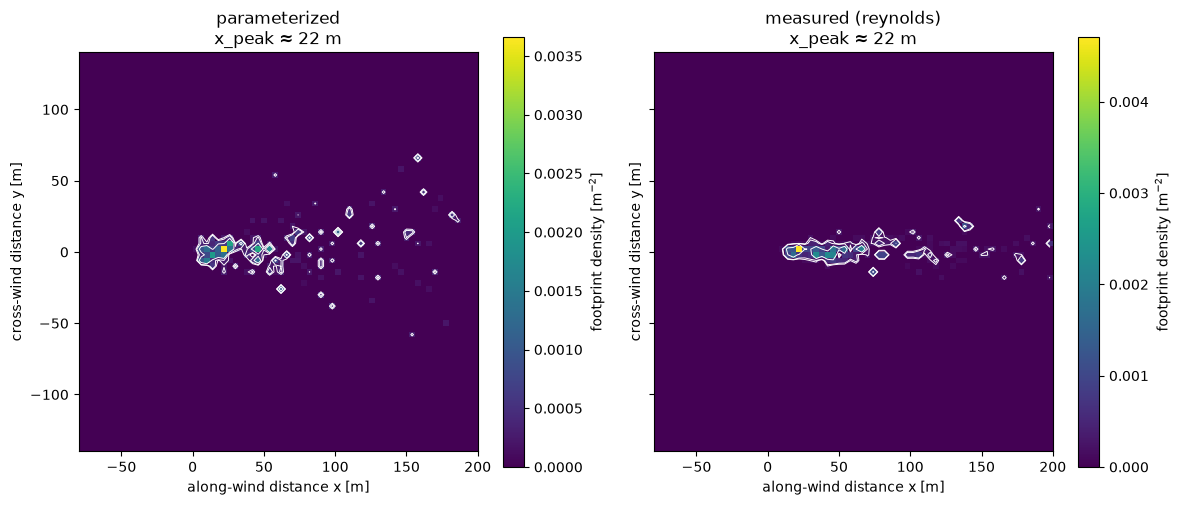

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
panels = [("parameterized", param), ("measured (reynolds)", reyn)]
for ax, (title, r) in zip(axes, panels, strict=True):
    lg.plot_footprint(r, ax=ax)
    lg.plot_contours(r, ax=ax, colors="white", linewidths=0.7)
    ax.set_title(f"{title}\nx_peak ≈ {r.x_peak:.0f} m")
fig.tight_layout()
plt.show()

## Crosswind-integrated footprint `f(x)`

Collapsing each footprint to `f(x) = ∫ f dy` makes the along-wind difference
between the two turbulence treatments easy to compare directly.

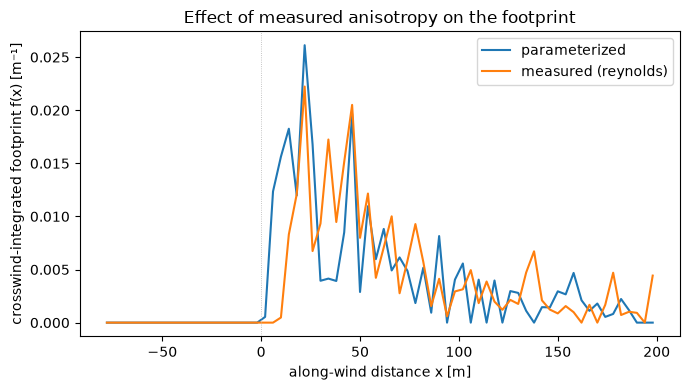

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(param.x, param.density.sum(axis=0) * grid.dy, label="parameterized")
ax.plot(reyn.x, reyn.density.sum(axis=0) * grid.dy, label="measured (reynolds)")
ax.axvline(0.0, color="0.7", lw=0.6, ls=":")
ax.set_xlabel("along-wind distance x [m]")
ax.set_ylabel("crosswind-integrated footprint f(x) [m⁻¹]")
ax.set_title("Effect of measured anisotropy on the footprint")
ax.legend()
fig.tight_layout()
plt.show()

The measured run uses the tower's own σ_w / σ_u / σ_v and their covariances rather
than MOST estimates, so its vertical mixing and along-wind reach can differ
noticeably from the parameterized baseline. With measured turbulence available,
prefer `mode="reynolds"` for the most site-specific footprint.